In [1]:
import os
import sys

import pandas as pd
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import joblib

from sklearnex import patch_sklearn
patch_sklearn()

import config as cfg
import re

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)


In [4]:
model_path = os.path.join(cfg.IMG_FULL_DATA_PATH, 'Day Time', 'daylight-30m-per-pixel', '2016', 'models', 'cluster_2016_1.joblib')

model = joblib.load(model_path)

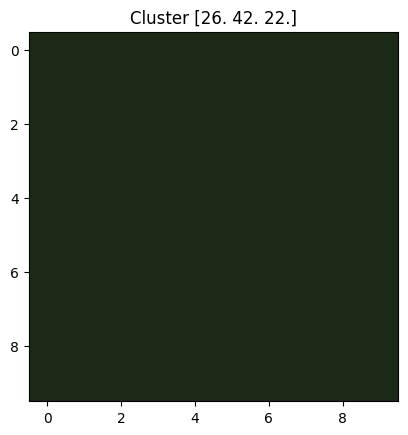

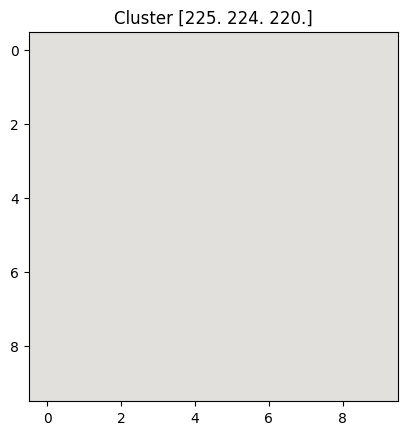

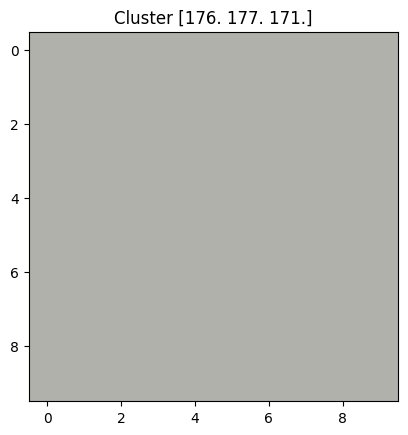

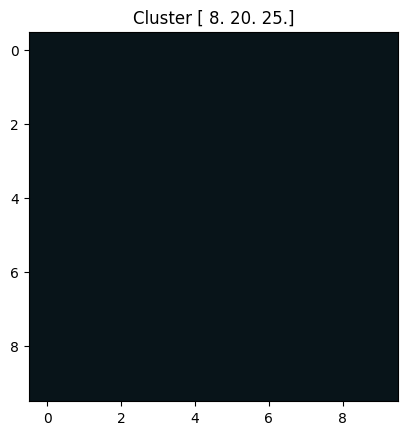

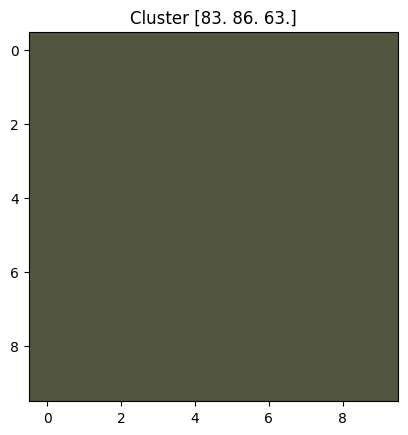

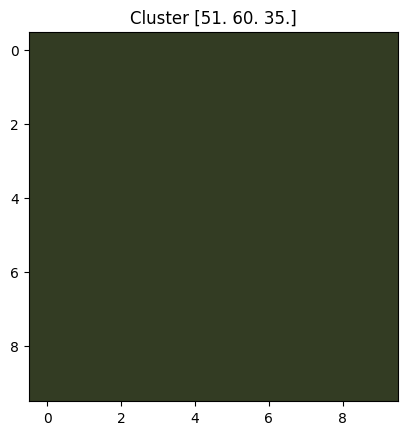

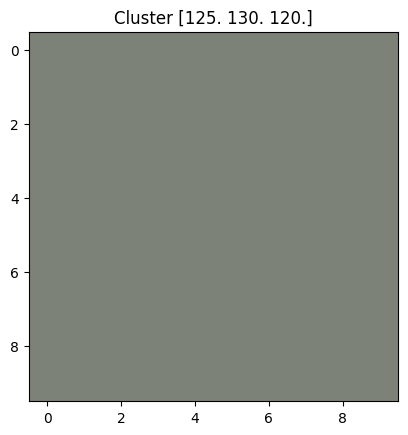

In [3]:
colors = pd.DataFrame(model.cluster_centers_, columns=['R', 'G', 'B'])

for i, colorvals in colors.iterrows():
    pixel = np.round(colorvals.values * 255.)
    color_img = np.array([pixel for i in range(0, 100)]).reshape(10, 10, 3).astype(int)
    plt.imshow(color_img)
    plt.title(f"Cluster {pixel}")
    plt.show()

In [4]:
cluster_maps = {
    'cloud': [1, 2, 6],
    'landmass': [0, 4, 5],
    'water': [3]
}

data = {
    'grid_num': [],
    'cloud_percentage': [],
    'landmass_percentage': [],
    'water_percentage': []
}

def calculate_feature_percentage(grid, feature):
    num_pixels = grid.shape[0]

    feature_count = grid.groupby('cluster')\
                        .count()\
                        .reset_index()\
                        .where(grid['cluster'].isin(cluster_maps[feature]))['R']\
                        .sum()
    
    return feature_count / num_pixels



# for grid_num, grid in grids.items():
#     reshaped_grid = pd.DataFrame(grid.reshape(grid.shape[0] * grid.shape[1], 3), columns=['R','G','B'])
    
#     for col in reshaped_grid.columns:
#         reshaped_grid[col] = reshaped_grid[col] / 255.

#     reshaped_grid['cluster'] = model.predict(reshaped_grid)

#     # cloud_density - Number of pixels in cluster 1, 4, 5
#     data['grid_num'].append(grid_num)

#     for feat in ['cloud', 'landmass', 'water']:
#         data[f'{feat}_percentage'].append(calculate_feature_percentage(reshaped_grid, feat))
    
#     print(f'Done Encoding Data {grid_num} to Tabular', end='\r')

# recom_pool = pd.DataFrame(data).sort_values(by='grid_num').set_index('grid_num')

In [5]:
processed_images = cfg.IMG_DATA_PATH
# CHANGE this:
dir =  r"daylight-30m-per-pixel"
#
cluster_maps = {
    'cloud': [1, 2, 6],
    'landmass': [0, 4, 5],
    'water': [3]
}

for year in os.listdir(os.path.join(processed_images, dir)):
    data = {
        'grid_num': [],
        'cloud_percentage': [],
        'landmass_percentage': [],
        'water_percentage': []
    }
    if year == '.DS_Store': continue
    grids = {}
    TARGET = f'daylight-{year}'
    print(TARGET)
    dir_path = os.path.join(processed_images, dir, year)
    count = 0
    for grid in os.listdir(dir_path):
        if grid == '.DS_Store': continue
        # if not grid.startswith(TARGET): continue

        img = cv.imread(os.path.join(dir_path, grid))
        img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

        # grid_num = int(re.findall(r'_(\d+).tiff', grid)[0])

        # grids[grid_num] = img
        grids[count] = img
        print(f'Added GRID_NUM {count}', end='\r')
        count += 1
    print(f'Added {count} grids')
    print(f'Added {year} to grids')
    print(f'Encoding {count} grids to tabular')
    count = 0
    for grid_num, grid in grids.items():
        reshaped_grid = pd.DataFrame(grid.reshape(grid.shape[0] * grid.shape[1], 3), columns=['R','G','B'])

        for col in reshaped_grid.columns:
            reshaped_grid[col] = reshaped_grid[col] / 255.

        reshaped_grid['cluster'] = model.predict(reshaped_grid)

        # cloud_density - Number of pixels in cluster 1, 4, 5
        data['grid_num'].append(grid_num)

        for feat in ['cloud', 'landmass', 'water']:
            data[f'{feat}_percentage'].append(calculate_feature_percentage(reshaped_grid, feat))

        print(f'Done Encoding Data {count} to Tabular', end='\r')
        count += 1
    
    recom_pool = pd.DataFrame(data).sort_values(by='grid_num').set_index('grid_num')
    recom_pool.to_csv(os.path.join(f'recommendation_pool/{dir}/', f'recom_pool_{year}.csv'))

daylight-2016
Added 30000 grids999
Added 2016 to grids
Encoding 30000 grids to tabular
daylight-2017 Data 29999 to Tabular
Added 27500 grids499
Added 2017 to grids
Encoding 27500 grids to tabular
daylight-2018 Data 27499 to Tabular
Added 30000 grids999
Added 2018 to grids
Encoding 30000 grids to tabular
daylight-2019 Data 29999 to Tabular
Added 30000 grids999
Added 2019 to grids
Encoding 30000 grids to tabular
daylight-2020 Data 29999 to Tabular
Added 30000 grids999
Added 2020 to grids
Encoding 30000 grids to tabular
